In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap
import warnings 
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

from config.constants import PROJECT_ROOT

data_path = str(PROJECT_ROOT / "saved_data" / "cohorts" / "DTB" / "selected_edges_DTB_all.csv")
save_dir = str(PROJECT_ROOT / "saved_data" / "plots" / "DTB") + "/"


os.makedirs(save_dir, exist_ok=True)

## Load Trajectories and add cohort features

In [4]:
df = pd.read_csv(data_path)
df = df[(df["n_pos"] > 10) & (df["n_neg"] > 50)].copy()

df["n_cohort"] = df["n_pos"] + df["n_neg"]
df["target_rate"] = df["n_pos"] / df["n_cohort"]
df["log_target_rate"] = np.log(df["target_rate"])
df["log_n_cohort"] = np.log(df["n_cohort"])
df["log_RR"] = np.log(df["RR"])
df["female_rate"] = df["female_counts"] / df["counts"]
df["death_rate"] = df["death_counts"] / df["counts"]
df["imbalance_ratio"] = df["n_neg"] / df["n_pos"]
df["log_imb"] = np.log(df["imbalance_ratio"])
#df = df [df["target_rate"] > 0.01]


icd_map = {
    "A": "infectious", "B": "infectious", "C": "neoplasms",
    "D": "blood", "E": "metabolic", "F": "mental",
    "G": "nervous", "H": "sensory", "I": "circulatory",
    "J": "respiratory", "K": "digestive", "L": "skin",
    "M": "musculoskeletal", "N": "genitourinary", "O": "pregnancy",
    "P": "perinatal", "Q": "congenital"
}
df["D1type"] = df["D1"].str[:1].map(icd_map)
df["D2type"] = df["D2"].str[:1].map(icd_map)

print(f"Total valid cohorts: {len(df)}")
df[["n_cohort", "target_rate", "RR", "CODE_DIFF_DAYS"]].describe()

df["cohort_name"] =  "cohort_" + df["D1"] + "_" + df["D2"] + "_" + df["CODE_DIFF_DAYS"].astype(str) 

possible_cohorts = df.copy()

Total valid cohorts: 4648


In [ ]:
# Cohorts are heavily right-skewed. Most cohorts are small a few very large
# Target rate imbalance across all cohorts
# RR most cohorts have modest relative risk but sume very strong
# Time window between D1 and D2 mostly consistent (1-2 years)


# For target_rate I didn't use log since the values near zero can result in very large negative numbers and dominate the clustering
# log only for n_cohort and RR

## Cohort Characteristics

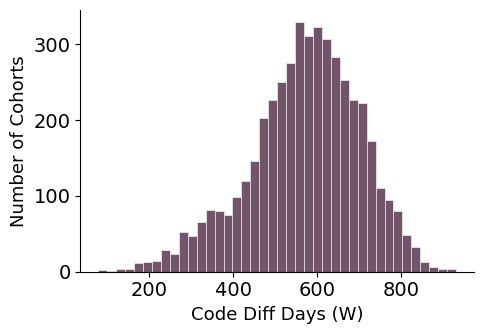

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

feats = ["target_rate","log_n_cohort","CODE_DIFF_DAYS","log_RR", "female_rate"]
labels = ["Positive Rate", "Log Cohort Size","Code Diff Days (W)","Log Relative Risk", "Female Rate"]
feat_labels = dict(zip(feats, labels))


feat = "CODE_DIFF_DAYS"

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.histplot(
    possible_cohorts[feat].dropna(),
    bins=40,
    ax=ax,
    color="#431C3A",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel(feat_labels[feat], fontsize=13)
ax.set_ylabel("Number of Cohorts", fontsize=13)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(save_dir + f"cohort_{feat}.png", dpi=300, bbox_inches="tight")
plt.show()


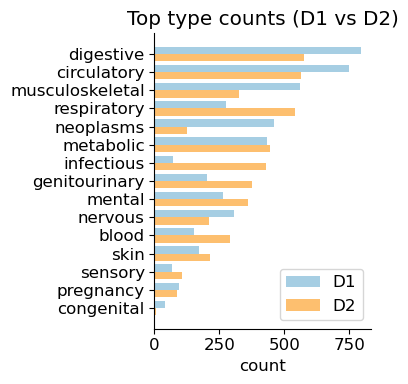

In [7]:
import numpy as np
import matplotlib.pyplot as plt

d1 = possible_cohorts["D1type"].value_counts()
d2 = possible_cohorts["D2type"].value_counts()

types = sorted(set(d1.index) | set(d2.index))

order = (
    pd.DataFrame({"D1": d1.reindex(types).fillna(0), "D2": d2.reindex(types).fillna(0)})
    .assign(max_=lambda x: x[["D1", "D2"]].max(axis=1))
    .sort_values("max_", ascending=False)
    .index.tolist()
)

D1 = d1.reindex(order).fillna(0).values
D2 = d2.reindex(order).fillna(0).values

y = np.arange(len(order))
h = 0.4  # bar height

fig, ax = plt.subplots(figsize=(4, 4))
ax.barh(y - h/2, D1, height=h, color="#A6CEE3", label="D1")
ax.barh(y + h/2, D2, height=h, color="#FDBF6F", label="D2")

ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()  # largest at top
ax.set_xlabel("count")
ax.set_title(f"Top type counts (D1 vs D2)")
ax.legend()
plt.tight_layout()
plt.savefig(save_dir + "DTB_cohorts_D1_D2_counts.png", dpi=150)
plt.show()

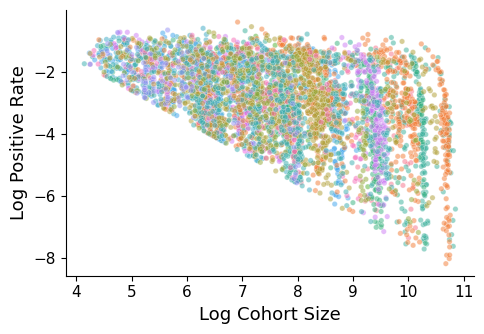

In [8]:
# Control seaborn's color order explicitly
hue_order = sorted(possible_cohorts["D1type"].dropna().unique())
palette_dict = dict(zip(hue_order, sns.color_palette("husl", len(hue_order))))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.scatterplot(
    data=possible_cohorts,
    x="log_n_cohort",
    y="log_target_rate",
    hue="D1type",
    hue_order=hue_order,
    palette="husl",
    s=15,
    alpha=0.5,
    legend=True,
    ax=ax,
)
ax.set_xlabel("Log Cohort Size", fontsize=13)
ax.set_ylabel("Log Positive Rate", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(
    title="D1 Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    markerscale=2,
    frameon=False,
    ncol=1,
)
ax.get_legend().remove()

plt.tight_layout()
plt.savefig(save_dir + "cohort_size_vs_target_rate_D1cat.png", dpi=300, bbox_inches="tight")
plt.show()


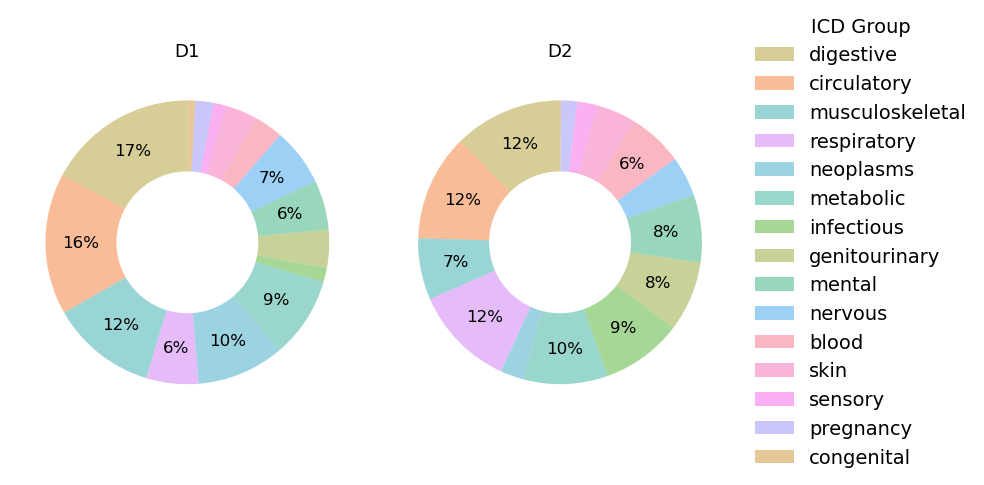

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (series, title) in zip(axes, [(d1.reindex(order), "D1"), (d2.reindex(order), "D2")]):
    wedges, _, autotexts = ax.pie(
        series.fillna(0),
        labels=None,
        autopct=lambda p: f"{p:.0f}%" if p > 5 else "",
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(width=0.5, alpha=0.5),
        colors=[palette_dict[cat] for cat in order],
    )
    for t in autotexts:
        t.set_fontsize(12)
    ax.set_title(title, fontsize=13)

axes[1].legend(
    wedges,
    order,
    title="ICD Group",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=14,
    title_fontsize=14,
    frameon=False,
)

plt.tight_layout()
plt.savefig(save_dir + "DTB_cohorts_D1_D2_donut.png", dpi=300, bbox_inches="tight")
plt.show()


## UMAP

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_feat = possible_cohorts[["cohort_name","log_n_cohort", "target_rate", "log_RR", "log_imb","AGE_AT_DISEASE", "female_rate", "death_rate","D1type", "D2type", "D1", "D2"]].dropna().copy()

for col in ["D1type", "D2type"]:
    df_feat[col + "_enc"] = LabelEncoder().fit_transform(df_feat[col].astype(str))

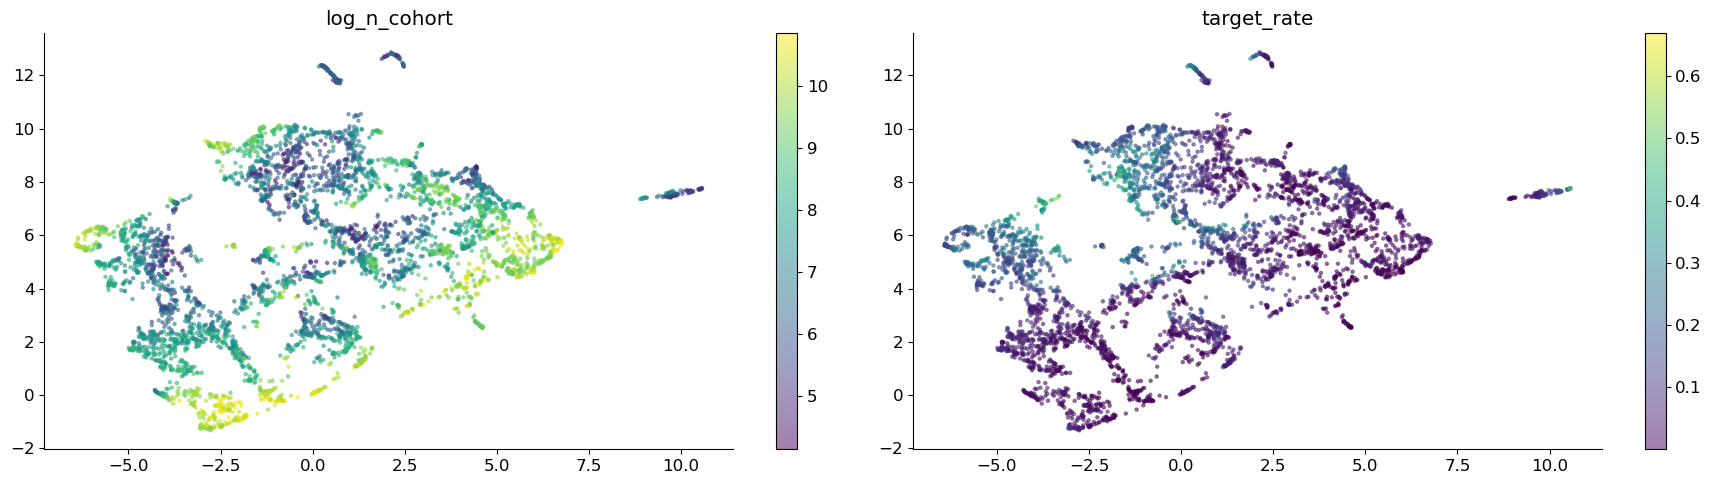

In [11]:

feat_cols = ["log_n_cohort", "target_rate", "log_RR", "log_imb", "female_rate", "death_rate","D1type_enc", "D2type_enc"]

X = StandardScaler().fit_transform(df_feat[feat_cols])

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(X)
df_feat["U1"] = coords[:, 0]
df_feat["U2"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in zip(axes, ["log_n_cohort", "target_rate"]):
    sc = ax.scatter(df_feat["U1"], df_feat["U2"], c=df_feat[col], cmap="viridis", s=5, alpha=0.5)
    plt.colorbar(sc, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(save_dir + "umap_features.png", dpi=150)
plt.show()

## K-means — elbow + silhouette

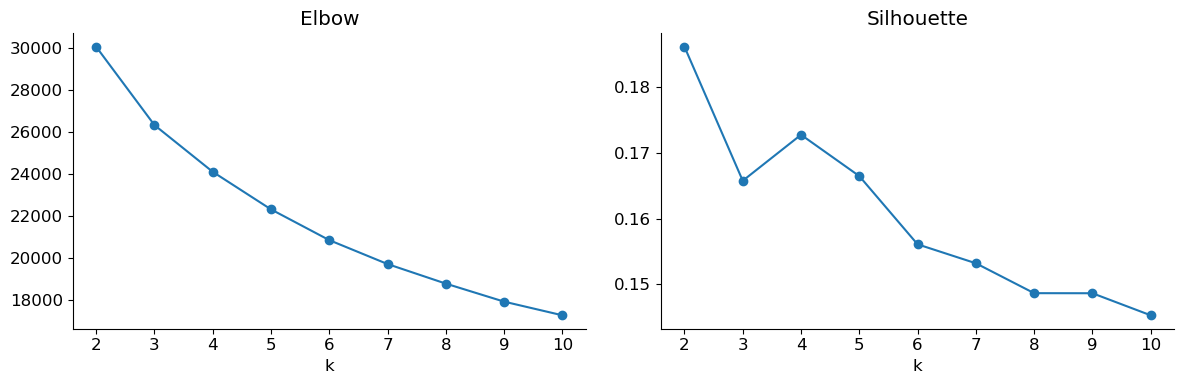

In [12]:

inertias, silhouettes = [], []
n_clusters = range(2, 11)

for k in n_clusters:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_clusters, inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_title("Elbow")
axes[1].plot(n_clusters, silhouettes, marker="o")
axes[1].set_xlabel("k")
axes[1].set_title("Silhouette")
plt.tight_layout()
plt.savefig(save_dir + "kmeans_selection.png", dpi=150)
plt.show()

## Apply clustering and describe clusters

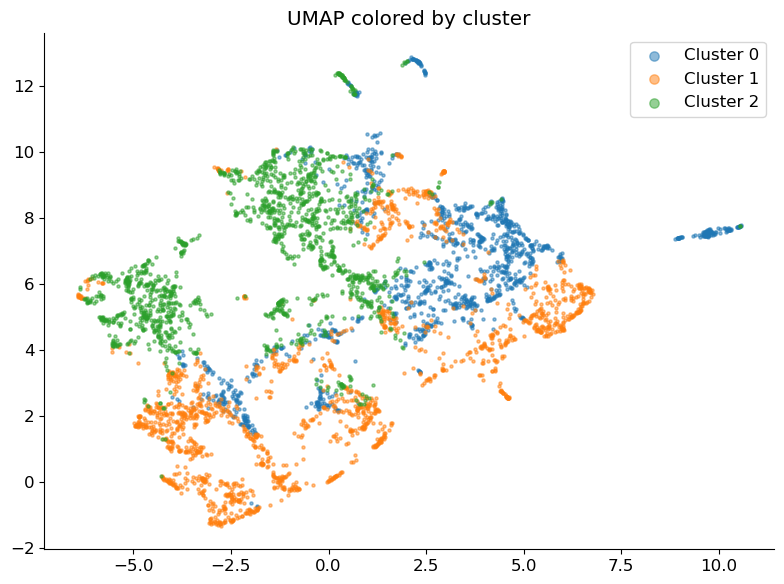

,log_n_cohort,target_rate,log_RR,log_imb,female_rate,death_rate,D1type_enc,D2type_enc
cluster,,,,,,,,
0,7.341,0.055,0.780,3.227,0.649,0.257,8.459,7.838
1,8.824,0.036,0.630,3.771,0.424,0.520,4.132,5.671
2,6.953,0.205,0.692,1.437,0.485,0.612,6.259,5.341


In [13]:

k = 3  # selected based on the above cell
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df_feat["cluster"] = km.fit_predict(X)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("tab10", k)
for c in range(k):
    sub = df_feat[df_feat["cluster"] == c]
    ax.scatter(sub["U1"], sub["U2"], label=f"Cluster {c}", color=palette[c], s=5, alpha=0.5)
ax.legend(markerscale=3)
ax.set_title("UMAP colored by cluster")
plt.tight_layout()
plt.savefig(save_dir + "umap_clusters.png", dpi=150)
plt.show()

df_feat[feat_cols + ["cluster"]].groupby("cluster").mean().round(3)

## Cluster entropy and heterogeneity

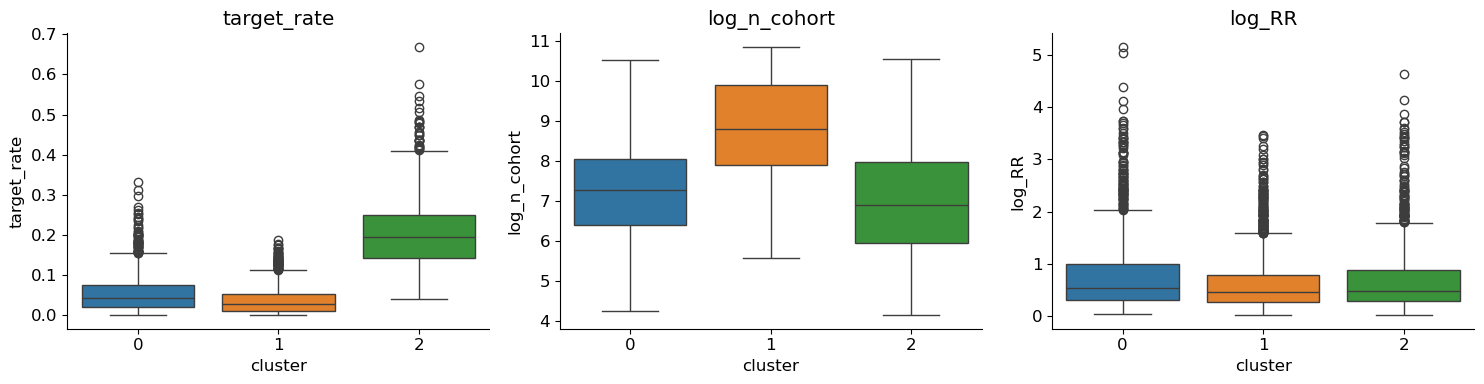

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["target_rate", "log_n_cohort", "log_RR"]):
    sns.boxplot(data=df_feat, x="cluster", y=feat, palette="tab10", ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig(save_dir + "cluster_distributions.png", dpi=150)#

plt.show()


In [15]:
print("Within-cluster std (heterogeneity):")
df_feat.groupby("cluster")[feat_cols].std().round(3)

Within-cluster std (heterogeneity):


,log_n_cohort,target_rate,log_RR,log_imb,female_rate,death_rate,D1type_enc,D2type_enc
cluster,,,,,,,,
0,1.272,0.046,0.716,1.005,0.184,0.191,3.376,3.887
1,1.221,0.032,0.538,1.212,0.132,0.195,3.186,4.151
2,1.390,0.086,0.629,0.544,0.161,0.187,3.916,3.794


## Disease type distribution per cluster

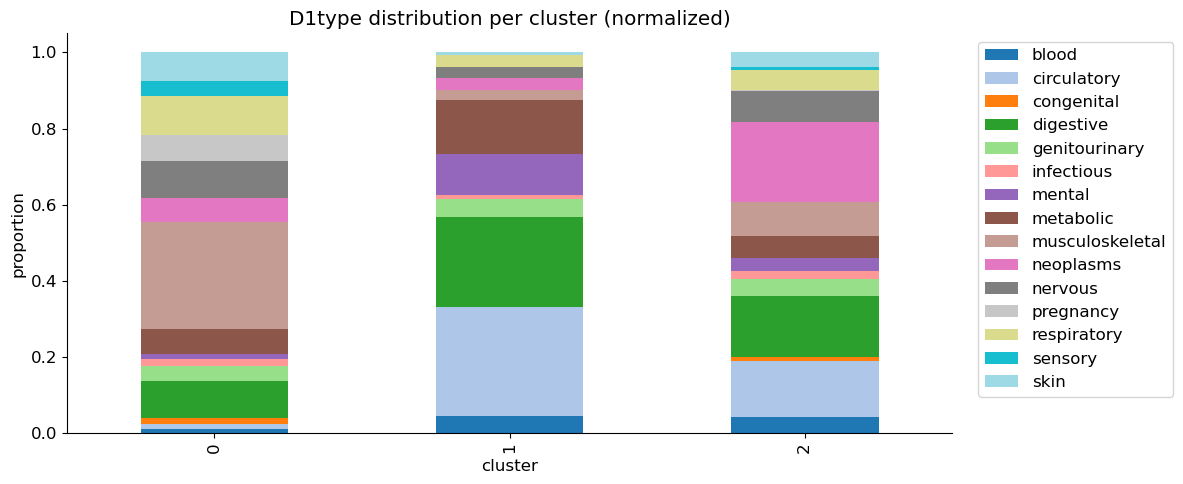

In [16]:
ct = pd.crosstab(df_feat["cluster"], df_feat["D1type"], normalize="index")

ct.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
plt.title("D1type distribution per cluster (normalized)")
plt.ylabel("proportion")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(save_dir + "cluster_D1type.png", dpi=150)
plt.show()

## Stratified sampling — representative cohorts

## based on k-mean clustering

In [17]:
# select 100 representative cohorts
# K-mean is used to groups the cohorts medoid is selected as representative cohort from each group

from sklearn.metrics import pairwise_distances
feat_cols = ["log_n_cohort", "target_rate", "log_RR", "log_imb", "female_rate", "death_rate","D1type_enc", "D2type_enc"]
X = StandardScaler().fit_transform(df_feat[feat_cols])

K = 100
km = KMeans(n_clusters=K, random_state=42, n_init=20)
labels = km.fit_predict(X)


rep_indices = []
for c in range(K):
    idx = np.where(labels == c)[0]
    center = km.cluster_centers_[c].reshape(1, -1)
    dists = pairwise_distances(X[idx], center).ravel()
    rep_indices.append(idx[np.argmin(dists)])
    
    
df_feat["cluster"] = labels   
df_feat["is_representative"] = False
df_feat.iloc[rep_indices, df_feat.columns.get_loc("is_representative")] = True

representative_cohorts = df_feat.iloc[rep_indices].copy().reset_index(drop=True)
df_feat.to_csv(PROJECT_ROOT / "saved_data" / "cohorts" / "DTB" / "cohorts_clusters.csv", index = False)

representative_cohorts["cohort_name"] = representative_cohorts["cohort_name"].apply(lambda x: "-".join(x.split("_")[1:3]))

representative_cohorts["cohort_name"].to_csv(PROJECT_ROOT / "saved_data" / "cohorts" / "DTB" /"representative_cohorts.txt",index=False, header=False)




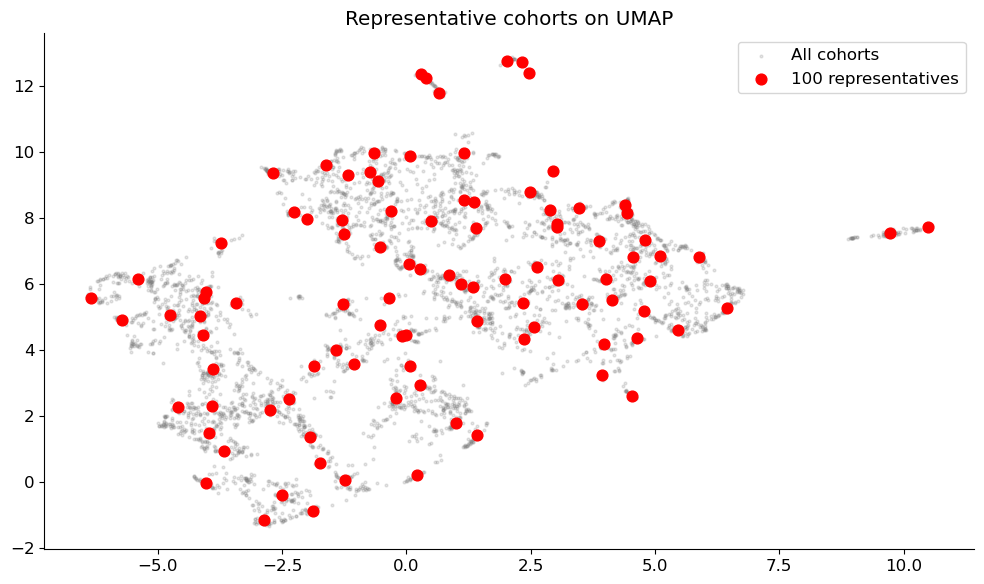

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_feat["U1"], df_feat["U2"], s=4, alpha=0.2, color="gray", label="All cohorts")
ax.scatter(df_feat[df_feat["is_representative"]]["U1"],
           df_feat[df_feat["is_representative"]]["U2"],
           s=60, color="red", zorder=5, label="100 representatives")
ax.set_title("Representative cohorts on UMAP")
ax.legend()
plt.tight_layout()
plt.savefig(save_dir + "representatives_on_umap.png", dpi=150)
plt.show()




## based on fixed intervals

In [36]:
# assign bins based on fix intervals
target_metrics = ["target_rate", "log_n_cohort"]

bin_labels = ["very_low", "low", "medium", "high"]
for target_metric, col_name in [("log_target_rate", "tr_group"), ("log_n_cohort", "cs_group")]:
    lo, hi = possible_cohorts[target_metric].min(), possible_cohorts[target_metric].max()
    step = (hi - lo) / 4
    bins = [lo + i * step for i in range(5)]
    possible_cohorts[col_name] = pd.cut(possible_cohorts[target_metric], bins=bins, labels=bin_labels, include_lowest=True)

In [37]:
## select metric
metric = "tr_group" # tr_group or cs_group 

high_cohort = possible_cohorts[possible_cohorts[metric] == "high"].head(10)
medium_cohort = possible_cohorts[possible_cohorts[metric] == "medium"].head(10)
low_cohort = possible_cohorts[possible_cohorts[metric] == "low"].head(10)
very_low_cohort = possible_cohorts[possible_cohorts[metric] == "very_low"].head(10)


# Build all cohorts df
selected_cohorts = pd.concat([high_cohort, medium_cohort, low_cohort, very_low_cohort])

## ML Results (old)

In [ ]:
from pathlib import Path
selected_cohorts = representative_cohorts
model ="CatBoost"
results_df = pd.DataFrame()
for cohort in selected_cohorts["cohort_name"]:
    file = dir = Path(f"/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/flabnet-pipeline/MIMIC_IV/saved_data/results/{cohort}/non_time_series/concatenate/minority/feature_selection_True/grid_False/feat_type_VMD/agg_interval_24h/2503/CatBoost_results.csv")
    if file.exists():
        output = pd.read_csv(file)
        output["cohort_name"] = cohort 
        results_df = pd.concat([results_df, output])
        
results_df =results_df[["cohort_name","Fold","AUC-ROC", "AUC-PRC", "f1_score"]]
for col in ["AUC-ROC", "AUC-PRC", "f1_score"]:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

for col, new_col in [("AUC-ROC", "roc_avg"), ("AUC-PRC", "pr_avg"), ("f1_score", "f1_avg")]:
    results_df[new_col] = results_df.groupby("cohort_name")[col].transform("mean")

results_df = results_df[["cohort_name", "roc_avg", "pr_avg", "f1_avg"]].drop_duplicates("cohort_name")
results_df =results_df.merge(selected_cohorts[["cohort_name","D1", "D2"]], on=["cohort_name"], how="inner")
results_df =results_df.merge(selected_cohorts[["D1", "D2", "target_rate", "n_cohort", "tr_group", "cs_group","RR", "female_counts", "log_imb"]], on=["D1", "D2"], how="inner")

results_df.sort_values(["roc_avg"], ascending=False)
results_df.to_csv("/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/FLabBench-pipeline/saved_data/plots/DTB/selected_cohorts_results.csv",index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df_merged = results_df.copy()
metric = "roc_avg"
group_col = "tr_group"
order = ["low", "medium", "high"]
palette = dict(zip(order, sns.color_palette("Set2", len(order))))

fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(
    data=df_merged.dropna(subset=[metric]),
    x=group_col, y=metric,
    order=order, palette=palette,
    jitter=0.25, alpha=0.5, size=4, ax=ax
)
sns.boxplot(
    data=df_merged.dropna(subset=[metric]),
    x=group_col, y=metric,
    order=order, palette=palette,
    width=0.4, fliersize=0, ax=ax
)
#ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.set_xlabel("Cohort size group", fontsize=11)
ax.set_ylabel(metric, fontsize=11)
ax.set_title("Model performance", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(save_dir + f"DTB_cohorts_{metric}_by_{group_col}.png", dpi=150)
plt.show()

## statistical analysis


In [ ]:
from scipy import stats
import scikit_posthocs as sp

metric = "pr_avg"
group_col = "tr_group"


data = df_merged.dropna(subset=["roc_avg"])
groups = [grp["roc_avg"].values for _, grp in data.groupby(group_col)]

stat, p = stats.kruskal(*groups)
dunn = sp.posthoc_dunn(data, val_col=metric, group_col=group_col, p_adjust="fdr_bh")

print(f"Kruskal-Wallis: H={stat:.3f}, p={p:.4f}")
print("\nDunn post-hoc p-values (BH corrected):")
print(dunn.round(4))

print("\nSignificantly different pairs (p < 0.05):")
order = ["very_low","low", "medium", "high"]
for i in range(len(order)):
    for j in range(i+1, len(order)):
        g1, g2 = order[i], order[j]
        pval = dunn.loc[g1, g2]
        sig = "YES ***" if pval < 0.001 else ("YES *" if pval < 0.05 else "no")
        print(f"  {g1} vs {g2}: p={pval:.4f}  →  {sig}")

## Feature analysis

### run compute_feature_stats instead of code below

In [ ]:
from tqdm import tqdm
from scipy.stats import entropy

import pickle
with open("/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/flabnet-pipeline/MIMIC_IV/saved_data/top_features/mimic_top100_features.pkl", "rb") as f:
    top_features = pickle.load(f)
top_features = set(int(x) for x in top_features)

results = pd.read_csv("/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/FLabBench-pipeline/saved_data/plots/DTB/selected_cohorts_results.csv")

cohorts = results.cohort_name


def feature_entropy(series):
    series = series.dropna()
    if series.std() > 0:
        series = (series - series.mean()) / series.std()
    counts, _ = np.histogram(series, bins=10)
    return entropy(counts + 1)


for cohort_name in tqdm(cohorts):
    cohort = pd.read_csv(f"/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/flabnet-pipeline/MIMIC_IV/saved_data/cohorts/{cohort_name}.csv")
    features = pd.read_csv(f"/Users/zy51nise/Documents/BIONETs/FLabNet/Code_main/flabnet-pipeline/MIMIC_IV/saved_data/features/{cohort_name}_admissions_labs_14_days.csv.gz")
    features = features[features["itemid"].isin(list(top_features)[:100])]
    features = features.merge(cohort[["hadm_id", "label"]], on="hadm_id")
    patient_feats = features.groupby(["hadm_id", "itemid"])["value"].mean().unstack()
    labels = cohort[["hadm_id", "label"]].drop_duplicates("hadm_id")
    patient_feats = patient_feats.merge(labels, on="hadm_id")
    missingness_var = patient_feats.drop(columns="label").isna().mean().var() # variation of missingness across features 
    results.loc[results["cohort_name"] == cohort_name, "missingness_v"] = missingness_var
    
    missingness_mean = patient_feats.drop(columns="label").isna().mean().mean() # overall average missingness rate
    results.loc[results["cohort_name"] == cohort_name, "missingness_m"] = missingness_mean
    
    pos = patient_feats[patient_feats["label"] == 1].drop(columns="label").mean()
    neg = patient_feats[patient_feats["label"] == 0].drop(columns="label").mean()
    
    feat_cols = patient_feats.drop(columns="label").columns
    h_pos = patient_feats[patient_feats["label"]==1][feat_cols].apply(feature_entropy).mean()
    h_neg = patient_feats[patient_feats["label"]==0][feat_cols].apply(feature_entropy).mean()
    
    results.loc[results["cohort_name"] == cohort_name, "h_pos"] = h_pos
    results.loc[results["cohort_name"] == cohort_name, "h_neg"] = h_neg
    

    pooled_std = patient_feats.drop(columns="label").std()
    cohens_d = ((pos - neg).abs() / (pooled_std + 1e-8)).mean()

    results.loc[results["cohort_name"] == cohort_name, "cohens_d"] = cohens_d

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), ["n_cohort", "target_rate", "missingness_m","missingness_v", "h_pos", "h_neg","log_imb", "RR"]): # female_counts
    sns.scatterplot(data=results, x=feat, y="roc_avg", ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig(save_dir + "features.png", dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(18, 6))
top_feats = patient_feats.drop(columns="label").columns[1:21]

for ax, col in zip(axes.ravel(), top_feats):
    patient_feats[patient_feats["label"]==1][col].dropna().hist(ax=ax, bins=20, alpha=0.5, label="pos", color="red",density=True)
    patient_feats[patient_feats["label"]==0][col].dropna().hist(ax=ax, bins=20, alpha=0.5, label="neg", color="blue",density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA

X = patient_feats.drop(columns="label").fillna(0)
X.columns = X.columns.astype(str)
coords = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
plt.scatter(coords[:,0], coords[:,1], c=patient_feats["label"], cmap="coolwarm", alpha=1, s=10)
plt.colorbar(label="label")
plt.title("PCA: pos vs neg patients")
plt.show()

# CHECK LATER

## Feature anaylsis for all 4000 cohorts

In [ ]:
# First run compute_feature_stats.py 

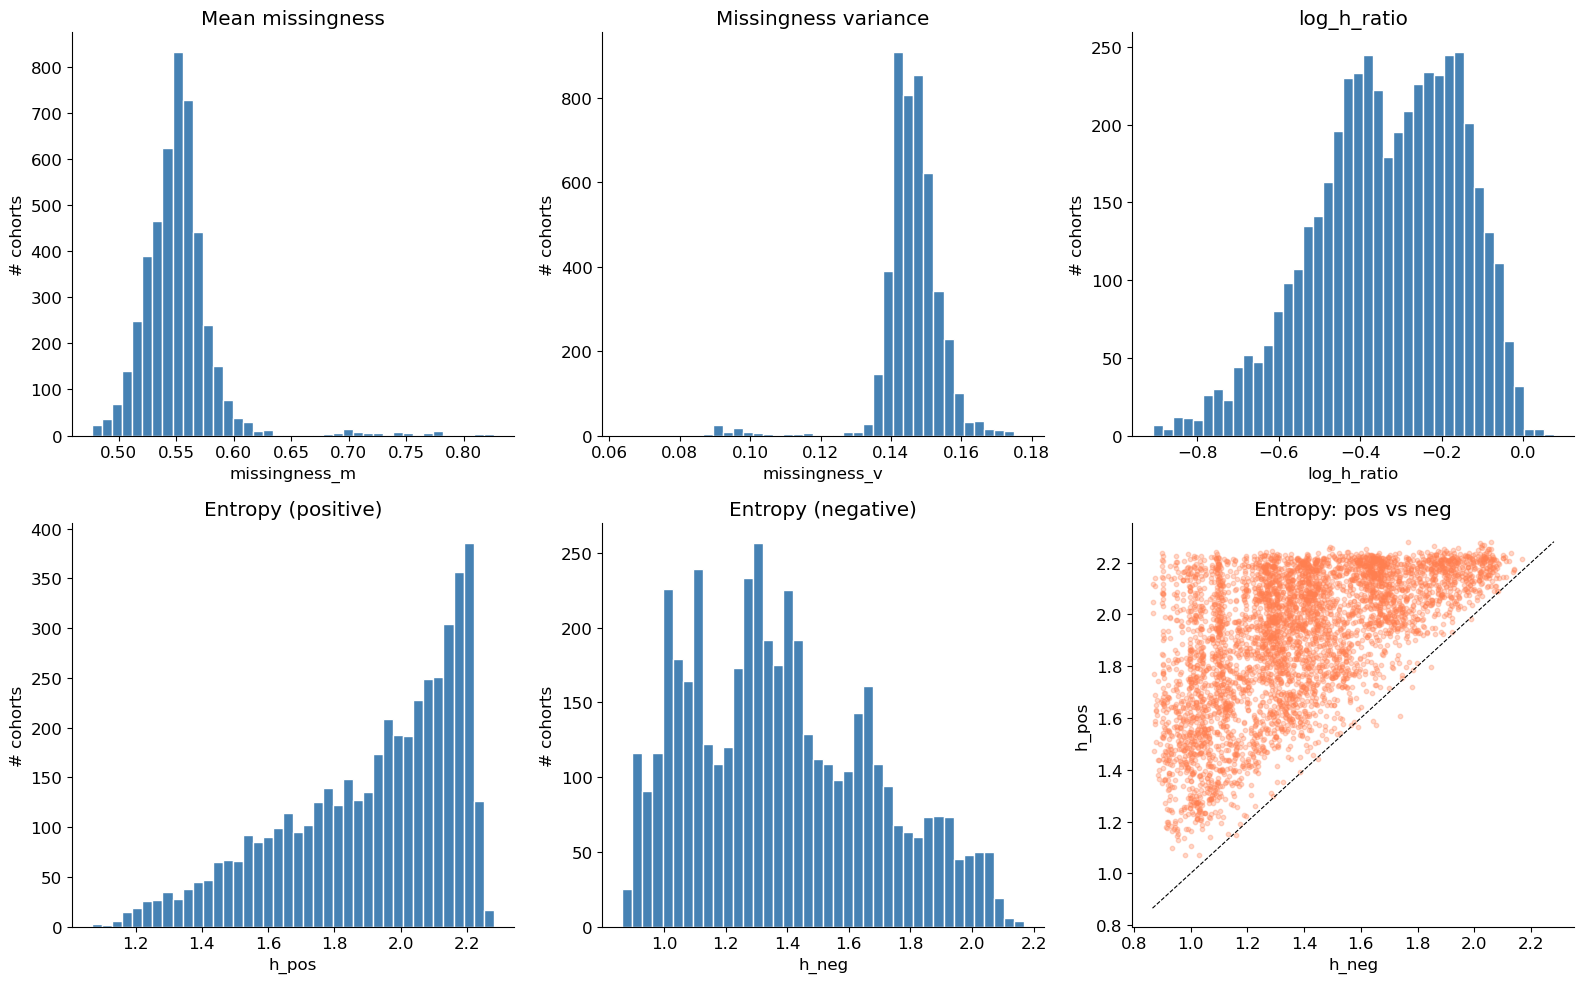

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = pd.read_csv("/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/features/feature_stats.csv")
features = features.drop(columns="AUC-mean")
features["cohort_name"] = features["cohort_name"].apply(lambda x: "-".join(x.split("_")[1:3]))

features["log_h_ratio"] = np.log(features["h_neg"] / features["h_pos"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = [
    ("missingness_m", "Mean missingness"),
    ("missingness_v", "Missingness variance"),
    ("log_h_ratio", "log_h_ratio"),
    ("h_pos", "Entropy (positive)"),
    ("h_neg", "Entropy (negative)"),
]

for ax, (col, title) in zip(axes.flatten(), metrics):
    ax.hist(features[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("# cohorts")

# Scatter: h_pos vs h_neg
axes[1, 2].scatter(features["h_neg"], features["h_pos"], alpha=0.3, s=10, color="coral")
lim = [min(features[["h_pos","h_neg"]].min()), max(features[["h_pos","h_neg"]].max())]
axes[1, 2].plot(lim, lim, "k--", lw=0.8)
axes[1, 2].set_title("Entropy: pos vs neg")
axes[1, 2].set_xlabel("h_neg")
axes[1, 2].set_ylabel("h_pos")
plt.savefig(save_dir + "feature_stats.png", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

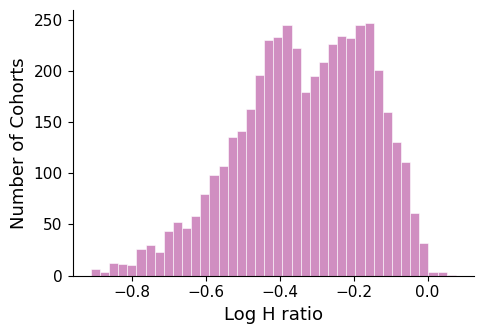

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

feats = ["missingness_m", "missingness_v","log_h_ratio", "h_neg", "h_pos"]
labels = ["Missingness Mean", "Missingness Variance", "Log H ratio", "H Positive", "H Negative"]
feat_labels = dict(zip(feats, labels))

feat = "log_h_ratio"

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.histplot(
    features[feat].dropna(),
    bins=40,
    ax=ax,
    color="#C169AD",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel(feat_labels[feat], fontsize=13)
ax.set_ylabel("Number of Cohorts", fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(save_dir + f"cohort_{feat}.png", dpi=300, bbox_inches="tight")
plt.show()


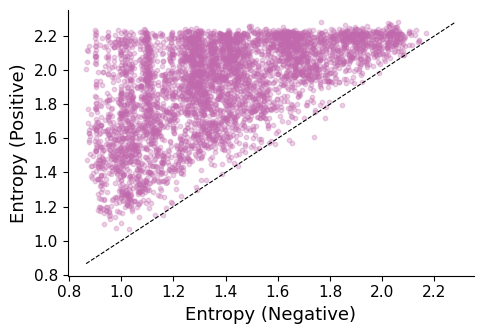

In [22]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(features["h_neg"], features["h_pos"], alpha=0.3, s=10, color="#C169AD")
lim = [min(features[["h_pos", "h_neg"]].min()), max(features[["h_pos", "h_neg"]].max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("Entropy (Negative)", fontsize=13)
ax.set_ylabel("Entropy (Positive)", fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(save_dir + "cohort_h_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


# ML results

In [23]:
selected_cohorts = representative_cohorts #100
features = features

select 50 cohorts based on RF results

In [24]:
from pathlib import Path
import glob

models = ["random_forest"] #"catboost", "random_forest", "xgboost"]

results_df = pd.DataFrame()
for cohort in selected_cohorts["cohort_name"]: 
    for model in models: 
        for fold in range(5):
            for file in Path(f"/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/results/{cohort}/{model}").glob(f"*/fold_{fold}/agg_int_24/impute_fill/variant_VMD/results_final.csv"):
                output = pd.read_csv(file)
                output["cohort_name"] = cohort 
                output["model"] = model 
                results_df = pd.concat([results_df, output])

        
results_df = results_df[["cohort_name","model","fold","auroc", "auprc", "f1"]]

for col in ["auroc", "auprc", "f1"]:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

for col, new_col in [("auroc", "roc_avg"), ("auprc", "pr_avg"), ("f1", "f1_avg")]:
    results_df[new_col] = results_df.groupby(["cohort_name", "model"])[col].transform("mean")


#across all cohorts and models
results_df = results_df[["cohort_name", "model", "roc_avg", "pr_avg", "f1_avg"]].drop_duplicates(["cohort_name", "model"])


In [27]:
selected_model = "random_forest"
sub_results = results_df[results_df.model == "random_forest"].sort_values("roc_avg", ascending = False)
#select Top 50 cohorts for random forest
rep_50 = sub_results.nlargest(50, "roc_avg")["cohort_name"]
rep_50.to_csv("/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/cohorts/DTB/representative_cohorts_top_50_RF.txt", index=False)

50 cohorts on Umap

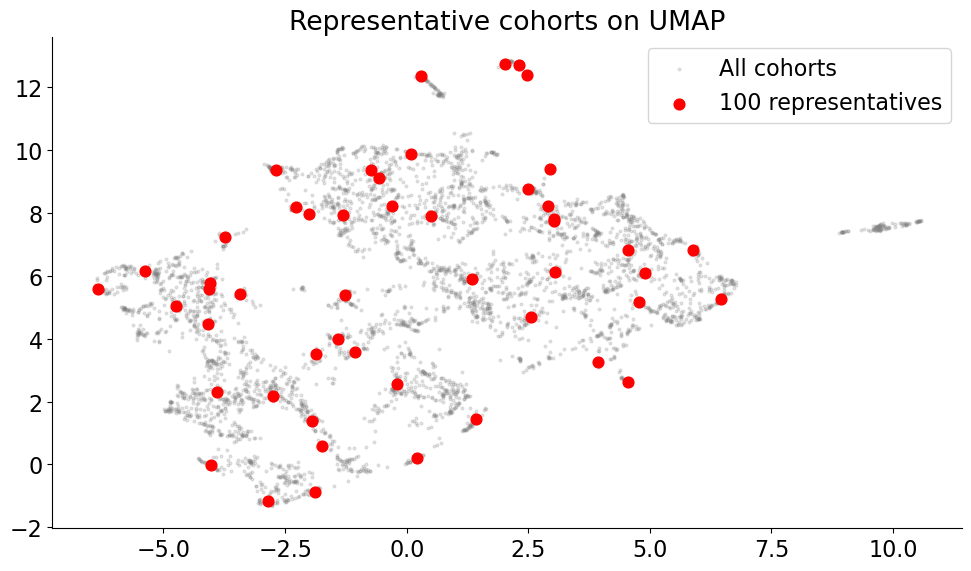

In [53]:
rep_50 = pd.read_csv("/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/cohorts/DTB/representative_cohorts_top_50_RF.txt")

df_feat = possible_cohorts[["cohort_name","log_n_cohort", "target_rate", "log_RR", "log_imb","AGE_AT_DISEASE", "female_rate", "death_rate","D1type", "D2type", "D1", "D2"]].dropna().copy()
df_feat["cohort_name"] = df_feat["D1"]+"-"+df_feat["D2"]
for col in ["D1type", "D2type"]:
    df_feat[col + "_enc"] = LabelEncoder().fit_transform(df_feat[col].astype(str))

feat_cols = ["log_n_cohort", "target_rate", "log_RR", "log_imb", "female_rate", "death_rate","D1type_enc", "D2type_enc"]

X = StandardScaler().fit_transform(df_feat[feat_cols])

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(X)
df_feat["U1"] = coords[:, 0]
df_feat["U2"] = coords[:, 1]

df_feat["is_representative"] = df_feat.cohort_name.isin(rep_50.cohort_name)


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_feat["U1"], df_feat["U2"], s=4, alpha=0.2, color="gray", label="All cohorts")
ax.scatter(df_feat[df_feat["is_representative"]]["U1"],
           df_feat[df_feat["is_representative"]]["U2"],
           s=60, color="red", zorder=5, label="100 representatives")
ax.set_title("Representative cohorts on UMAP")
ax.legend()
plt.tight_layout()
plt.savefig(save_dir + "representatives_on_umap.png", dpi=150)
plt.show()



analyze results for all models for 50 cohorts

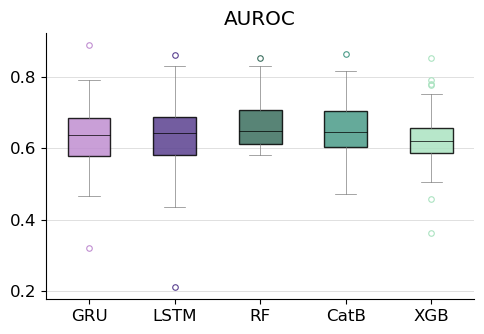

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


metric     = "auroc"   # "auroc", "auprc", or "f1"
metric_label = {"auroc": "AUROC", "auprc": "AUPRC", "f1": "F1"}

rep_50_cohorts = pd.read_csv("/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/cohorts/DTB/representative_cohorts_top_50_RF.txt",header=None)[0].tolist()

models = ["gru", "lstm", "random_forest", "catboost", "xgboost"]
model_labels = ["GRU", "LSTM", "RF", "CatB", "XGB"]
colors = ["#C08ED1", "#5A4190", "#3B6E5E", "#4A9B88", "#ABE3C1"]

base = Path("/home/atuin/b310dc/b310dc10/FLabBench-pipeline/saved_data/results/")

rows = []
for cohort in rep_50_cohorts:
    for model in models:
        for f in (base / cohort / model).glob("*/fold_*/agg_int_24/impute_fill/variant_VMD/results_final.csv"):
            df = pd.read_csv(f, usecols=["auroc", "auprc", "f1"])
            df["cohort_name"] = cohort
            df["model"] = model
            rows.append(df)

results_df = pd.concat(rows, ignore_index=True)
for col in ["auroc", "auprc", "f1"]:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

per_cohort = results_df.groupby(["cohort_name", "model"])[["auroc", "auprc", "f1"]].mean().reset_index()
data = [per_cohort[per_cohort.model == m][metric].dropna().values for m in models]

fig, ax = plt.subplots(figsize=(5, 3.5))
bp = ax.boxplot(
    data, patch_artist=True, widths=0.5,
    medianprops=dict(color="black", linewidth=0.5),
    whiskerprops=dict(color="gray", linewidth=0.5),
    capprops=dict(color="gray", linewidth=0.5),
    flierprops=dict(marker="o", markersize=4, linestyle="none",
                    markerfacecolor="none", markeredgewidth=0.8),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for flier, color in zip(bp["fliers"], colors):
    flier.set_markeredgecolor(color)

ax.set_xticks(range(1, len(models) + 1))
ax.set_xticklabels(model_labels)
ax.set_title(metric_label[metric])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="lightgray", linewidth=0.5, zorder=2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(save_dir + f"boxplot_{metric}_top50.png", dpi=300, bbox_inches="tight")
plt.show()


# Performance vs Cohort characteristics

In [43]:
df_merged = per_cohort.merge(selected_cohorts[["cohort_name", "D1", "D2", "target_rate", "log_n_cohort", "log_RR", "female_rate", "death_rate"]],on="cohort_name",how="inner")
df_merged = df_merged.merge(features,on="cohort_name",how="inner")



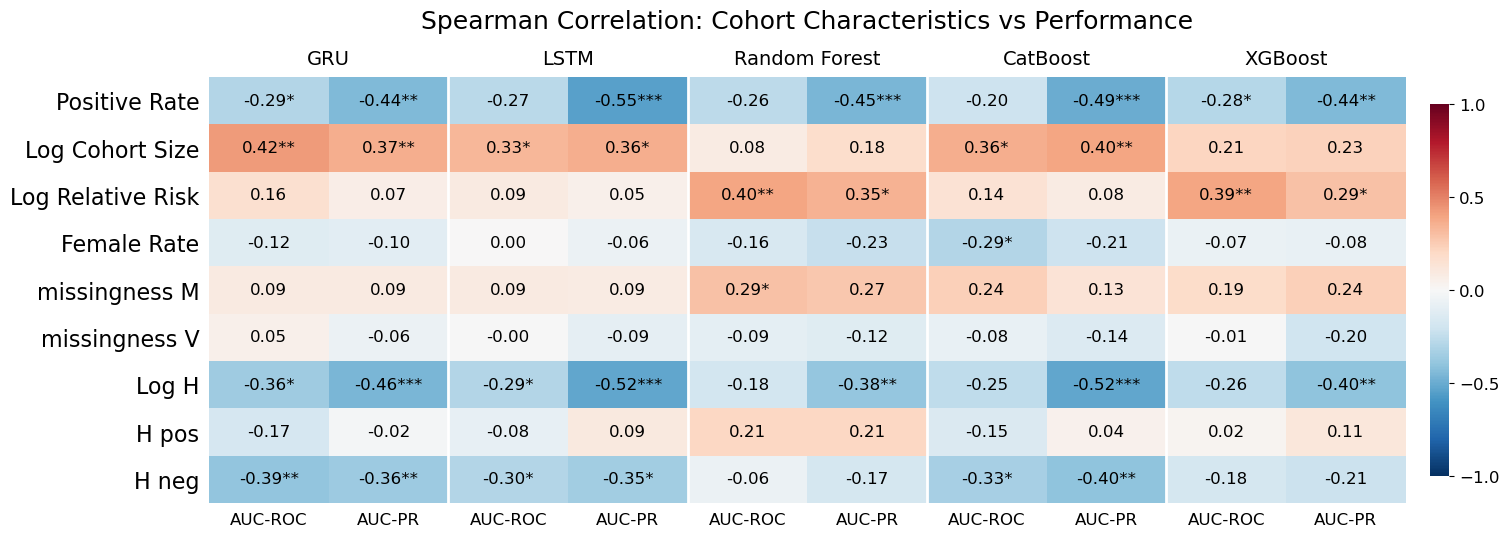

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from scipy.stats import spearmanr

# normalized AUPRC
df_merged["auprc_norm"] = df_merged["auprc"] / df_merged["target_rate"]

char_cols   = ["target_rate", "log_n_cohort", "log_RR", "female_rate",
               "missingness_m", "missingness_v", "log_h_ratio", "h_pos", "h_neg"]
char_labels = ["Positive Rate", "Log Cohort Size", "Log Relative Risk", "Female Rate",
               "missingness M", "missingness V", "Log H", "H pos", "H neg"]
models       = ["gru", "lstm", "random_forest", "catboost", "xgboost"]
model_labels = ["GRU", "LSTM", "Random Forest", "CatBoost", "XGBoost"]
metrics      = ["auroc", "auprc_norm"]
metric_labels = ["AUC-ROC", "AUC-PR"]

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ── correlations ────────────────────────────────────────────────────
cols = [f"{m}_{mt}" for m in models for mt in metrics]
corr_matrix = pd.DataFrame(index=char_cols, columns=cols, dtype=float)
star_matrix = pd.DataFrame(index=char_cols, columns=cols, dtype=str)

for m in models:
    sub = df_merged[df_merged.model == m]
    for mt in metrics:
        for c in char_cols:
            valid = sub[[c, mt]].dropna()
            r, p = spearmanr(valid[c], valid[mt])
            corr_matrix.loc[c, f"{m}_{mt}"] = r
            star_matrix.loc[c, f"{m}_{mt}"] = sig_stars(p)


plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 16})

fig, ax = plt.subplots(figsize=(16, 6))
fig.subplots_adjust(top=0.82)

corr_vals = corr_matrix.values.astype(float)
im = ax.imshow(corr_vals, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

for i in range(len(char_cols)):
    for j in range(len(cols)):
        r = corr_vals[i, j]
        stars = star_matrix.iloc[i, j]
        ax.text(j, i, f"{r:.2f}{stars}", ha="center", va="center",
                fontsize=12, color="black" if abs(r) < 0.6 else "white")


ax.set_xticks(range(len(cols)))
ax.set_xticklabels(metric_labels * len(models), fontsize=12)
ax.tick_params(axis="x", bottom=False)


ax.set_yticks(range(len(char_labels)))
ax.set_yticklabels(char_labels, fontsize=16)
ax.tick_params(axis="y", left=False)


trans = blended_transform_factory(ax.transData, ax.transAxes)
for idx, label in enumerate(model_labels):
    center = idx * len(metrics) + (len(metrics) - 1) / 2
    ax.text(center, 1.02, label, ha="center", va="bottom",
            fontsize=14, transform=trans)

for idx in range(1, len(models)):
    ax.axvline(x=idx * len(metrics) - 0.5, color="white", linewidth=2)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Spearman Correlation: Cohort Characteristics vs Performance",
             fontsize=18, pad=35)


cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
cbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_visible(False)

plt.savefig(save_dir + "spearman_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# Find largest Cohort

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = "/Users/zy51nise/Documents/BIONETs/FLabNet/Code/FLabBench-pipeline/data/MIMIC_IV/cohorts/DTB/"
sel_edges = pd.read_csv(root_dir + "selected_edges_DTB_all.csv")


possible_cohorts = sel_edges[(sel_edges["n_pos"] > 10) & (sel_edges["n_neg"] > 50)]
possible_cohorts["n_cohort"] = possible_cohorts["n_pos"] + possible_cohorts["n_neg"]
possible_cohorts["target_rate"] = possible_cohorts["n_pos"] / possible_cohorts["n_cohort"]
possible_cohorts["log_n_cohort"] = np.log(possible_cohorts["n_cohort"])
possible_cohorts["log_target_rate"] = np.log(possible_cohorts["target_rate"])

sub_cohorts =possible_cohorts[possible_cohorts['target_rate'] > 0.01]
sub_cohorts.sort_values(by='n_cohort', ascending=False).head(5)


In [ ]:
cohort = pd.read_csv(root_dir + "cohort_E78_H35_791.08.csv.gz", compression="gzip")
print(cohort["label"].sum())
print(len(cohort))